In [1]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving cleaned_student_performance (1).csv to cleaned_student_performance (1).csv


In [2]:
df = pd.read_csv("cleaned_student_performance (1).csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.shape

(6607, 20)

In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235508
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.889161
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,100.000000


In [5]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df[["Hours_Studied", "Exam_Score"]].corr()

,Hours_Studied,Exam_Score
Hours_Studied,1.000000,0.445558
Exam_Score,0.445558,1.000000


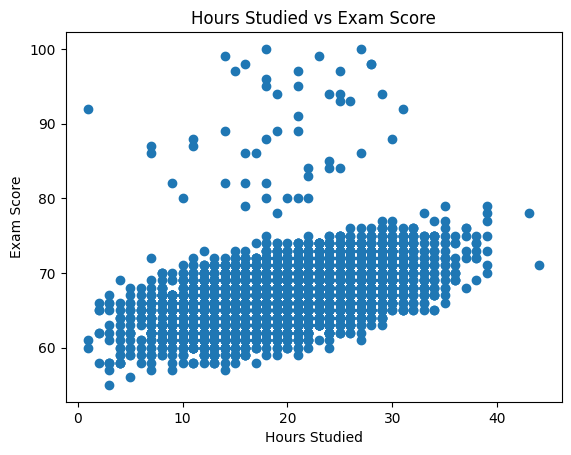

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

In [9]:
df[["Attendance", "Exam_Score"]].corr()

,Attendance,Exam_Score
Attendance,1.000000,0.581205
Exam_Score,0.581205,1.000000


In [11]:
df[["Previous_Scores", "Exam_Score"]].corr()

,Previous_Scores,Exam_Score
Previous_Scores,1.000000,0.175089
Exam_Score,0.175089,1.000000


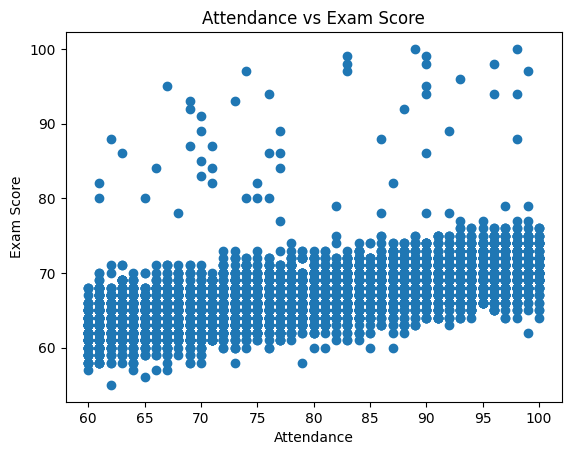

In [10]:
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()


In [12]:
df[["Sleep_Hours", "Exam_Score"]].corr()

,Sleep_Hours,Exam_Score
Sleep_Hours,1.000,-0.017
Exam_Score,-0.017,1.000


In [13]:
df[["Tutoring_Sessions", "Exam_Score"]].corr()


,Tutoring_Sessions,Exam_Score
Tutoring_Sessions,1.000000,0.156466
Exam_Score,0.156466,1.000000


In [14]:
Q1 = df["Hours_Studied"].quantile(0.25)
Q3 = df["Hours_Studied"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: 4.0
Upper limit: 36.0


In [15]:
anomalies = df[(df["Hours_Studied"] < lower) | (df["Hours_Studied"] > upper)]

print("Number of anomalies:", len(anomalies))

Number of anomalies: 43


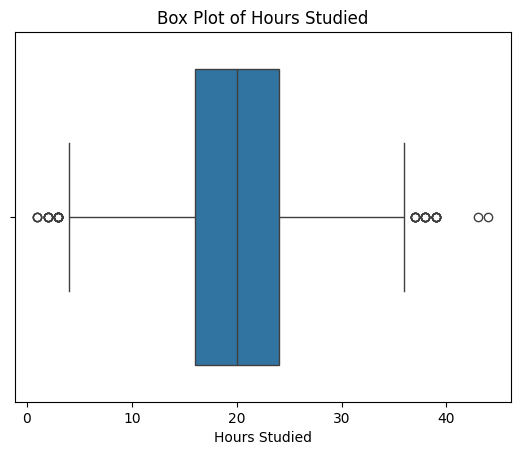

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Hours_Studied"])
plt.title("Box Plot of Hours Studied")
plt.xlabel("Hours Studied")
plt.show()

In [17]:
df.groupby("Parental_Involvement")["Exam_Score"].mean()

,Exam_Score
Parental_Involvement,
High,68.092767
Low,66.357517
Medium,67.098156


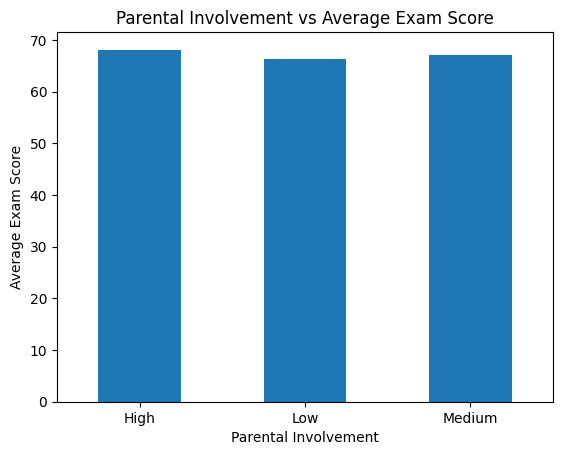

In [18]:

import matplotlib.pyplot as plt

df.groupby("Parental_Involvement")["Exam_Score"].mean().plot(kind="bar")

plt.xlabel("Parental Involvement")
plt.ylabel("Average Exam Score")
plt.title("Parental Involvement vs Average Exam Score")
plt.xticks(rotation=0)
plt.show()


In [19]:
df.groupby("Teacher_Quality")["Exam_Score"].mean()

,Exam_Score
Teacher_Quality,
High,67.676425
Low,66.753425
Medium,67.109299
Unknown,66.641026


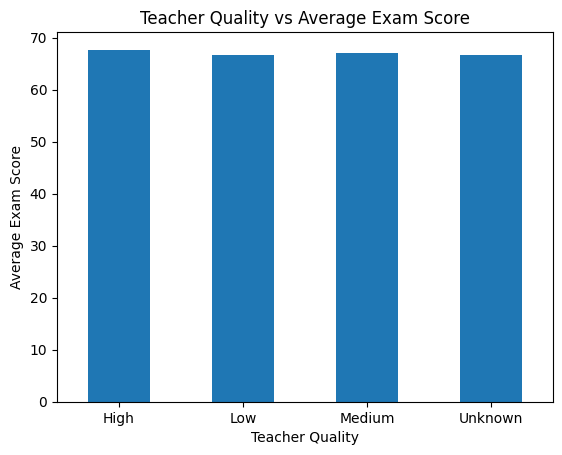

In [20]:
df.groupby("Teacher_Quality")["Exam_Score"].mean().plot(kind="bar")

plt.xlabel("Teacher Quality")
plt.ylabel("Average Exam Score")
plt.title("Teacher Quality vs Average Exam Score")
plt.xticks(rotation=0)
plt.show()

In [21]:
df.groupby("Motivation_Level")["Exam_Score"].mean()

,Exam_Score
Motivation_Level,
High,67.704321
Low,66.751678
Medium,67.330648


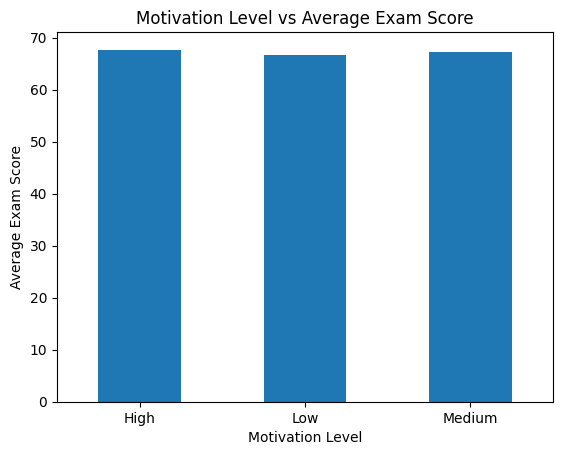

In [22]:
df.groupby("Motivation_Level")["Exam_Score"].mean().plot(kind="bar")

plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")
plt.title("Motivation Level vs Average Exam Score")
plt.xticks(rotation=0)
plt.show()

# Exploratory Data Analysis – Student Performance Dataset

## Objective
To explore the cleaned student performance dataset, identify trends, patterns, anomalies, and useful insights using Python and visualizations.

In [23]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6607
Number of columns: 20


In [24]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235508
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.889161
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,100.000000


## Key Insights

1. Hours Studied and Exam Score have a moderate positive relationship (correlation = 0.446).

2. Attendance and Exam Score have a moderate positive relationship (correlation = 0.581).

3. Previous Scores have a weak positive relationship with Exam Score (correlation = 0.175).

4. Sleep Hours show almost no linear relationship with Exam Score (correlation = -0.017).

5. Tutoring Sessions show a weak positive relationship with Exam Score (correlation = 0.156).

6. Students with high parental involvement have the highest average exam score (68.09).

7. Students in the High Teacher Quality group have the highest average exam score (67.68).

8. Students with high motivation have the highest average exam score (67.70).

9. The IQR method identified 43 students with unusual Hours Studied values outside the normal range of 4 to 36 hours.